# Story Generation with a Word-Level LSTM

Predicts the **next word** from the words before it, then feeds its own output
back in to build up a passage.

**Pipeline:** load text → lowercase & strip punctuation → build word index →
cumulative n-gram sequences → pad → `Embedding` → `Bidirectional(LSTM)` →
`Dense(softmax)` → generate.

**Dataset:** Tiny Shakespeare (1.1 MB, public domain), downloaded in §1.

> **On Colab:** Runtime → Change runtime type → **T4 GPU**, then Run all.
> Roughly 10 minutes on a GPU.

In [1]:
import os
import re

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM

# pad_sequences moved between Keras 2 and Keras 3; this works on both
try:
    from tensorflow.keras.preprocessing.sequence import pad_sequences
except ImportError:
    from tensorflow.keras.utils import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "none (CPU — this will be slow)")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load and clean the text

Lowercase and remove punctuation, as the task specifies.

In [2]:
import urllib.request

DATA_PATH = "input.txt"
DATA_URL = ("https://raw.githubusercontent.com/karpathy/char-rnn/"
            "master/data/tinyshakespeare/input.txt")

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

text = open(DATA_PATH, encoding="utf-8").read().lower()
text = re.sub(r"[^a-z\n ]", "", text)     # drop punctuation and digits
text = re.sub(r"[ \t]+", " ", text)       # collapse runs of spaces

lines = [ln.strip() for ln in text.split("\n") if ln.strip()]

print(f"lines: {len(lines):,}")
print(f"words: {len(text.split()):,}")
print("\n".join(lines[:6]))

lines: 32,777
words: 202,619
first citizen
before we proceed any further hear me speak
all
speak speak
first citizen
you are all resolved rather to die than to famish


## 2. Build the word index

A word → integer mapping. Index **0 is reserved for padding**, so real words
start at 1.

In [3]:
words = text.split()
vocabulary = sorted(set(words))

word2idx = {w: i + 1 for i, w in enumerate(vocabulary)}   # 0 = padding
idx2word = {i: w for w, i in word2idx.items()}
total_words = len(word2idx) + 1

print(f"total_words (vocab + padding): {total_words:,}")
print("first 10 words:", list(word2idx)[:10])

total_words (vocab + padding): 12,848
first 10 words: ['a', 'abandond', 'abase', 'abate', 'abated', 'abbey', 'abbot', 'abed', 'abels', 'abet']


## 3. Input → output pairs

For each line, take every growing prefix. The line `"we are accounted poor"`
becomes:

| input | output |
|---|---|
| `we` | `are` |
| `we are` | `accounted` |
| `we are accounted` | `poor` |

So each example is the words so far, and the label is the word that follows.
Sequences are left-padded to a common length.

**One change from the usual version of this code:** the labels stay as plain
integers instead of being one-hot encoded with `to_categorical`. One-hot here
would be ~200,000 sequences × ~12,000 vocabulary × 4 bytes ≈ **9.6 GB** and
would crash the runtime. `sparse_categorical_crossentropy` in §4 does exactly
the same thing from integer labels.

In [4]:
MAX_LEN = 20        # cap on words of context (long lines get their tail kept)

input_sequence = []
for line in lines:
    token_list = [word2idx[w] for w in line.split() if w in word2idx]
    for i in range(1, len(token_list)):
        # keep the last MAX_LEN tokens so one long line can't stretch every row
        input_sequence.append(token_list[max(0, i + 1 - MAX_LEN):i + 1])

max_length = max(len(x) for x in input_sequence)
input_pad = pad_sequences(input_sequence, maxlen=max_length, padding="pre")

predictors, label = input_pad[:, :-1], input_pad[:, -1]

# Hold out the last 10% as a TEST set. Training never sees it, and unlike the
# validation set it never influences early stopping or checkpointing either --
# so it is the only unbiased estimate of how the model does on unseen text.
n_test = int(len(predictors) * 0.1)
X_test, y_test = predictors[-n_test:], label[-n_test:]
X_train, y_train = predictors[:-n_test], label[:-n_test]

print(f"sequences  : {len(input_sequence):,}")
print(f"max_length : {max_length}")
print(f"predictors : {predictors.shape}")
print(f"label      : {label.shape}")
print(f"train      : {X_train.shape[0]:,}  (10% of this becomes validation)")
print(f"test       : {X_test.shape[0]:,}  (held out, never trained on)")
print(f"memory     : {predictors.nbytes / 1e6:.1f} MB")

print("\nexample —")
print("  input :", " ".join(idx2word[i] for i in predictors[5] if i != 0))
print("  output:", idx2word[label[5]])

sequences  : 169,842
max_length : 16
predictors : (169842, 15)
label      : (169842,)
train      : 152,858  (10% of this becomes validation)
test       : 16,984  (held out, never trained on)
memory     : 10.2 MB

example —
  input : before we proceed any further
  output: hear


## 4. Build the model

| Layer | Role |
|---|---|
| `Embedding(total_words, 100)` | a 100-dim vector per word |
| `Bidirectional(LSTM(150))` | reads the context forwards and backwards |
| `Dense(total_words, softmax)` | probability over every word in the vocabulary |

`sparse_categorical_crossentropy` is the integer-label form of categorical
crossentropy — same loss, no one-hot array.

In [5]:
model = Sequential([
    Embedding(total_words, 100),
    Bidirectional(LSTM(150)),
    Dense(total_words, activation="softmax"),
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

model.build(input_shape=(None, max_length - 1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 100)        │     1,284,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300)            │       301,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12848)          │     3,867,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,453,248 (20.80 MB)

 Trainable params: 5,453,248 (20.80 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train

`validation_split=0.1` holds out 10% to detect overfitting.
`ModelCheckpoint` keeps the best weights and `EarlyStopping` halts once
validation loss stops improving — the task's overfitting requirement.

In [6]:
callbacks = [
    ModelCheckpoint("word_lstm.keras", monitor="val_loss",
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=3,
                  restore_best_weights=True, verbose=1),
]

# 5 epochs: on this corpus val_loss bottoms out at epoch 5 and rises after,
# so anything beyond it is discarded by restore_best_weights anyway.
EPOCHS = 5

history = model.fit(X_train, y_train,
                    validation_split=0.1,
                    epochs=EPOCHS,
                    batch_size=256,
                    callbacks=callbacks,
                    verbose=1)

print(f"\nepochs run   : {len(history.history['loss'])}")
print(f"best val_loss: {min(history.history['val_loss']):.4f}")

Epoch 1/5
537/538 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0323 - loss: 7.2561
Epoch 1: val_loss improved from None to 6.76507, saving model to word_lstm.keras

Epoch 1: finished saving model to word_lstm.keras
538/538 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.0372 - loss: 6.9456 - val_accuracy: 0.0391 - val_loss: 6.7651
Epoch 2/5
535/538 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0499 - loss: 6.5390
Epoch 2: val_loss improved from 6.76507 to 6.51827, saving model to word_lstm.keras

Epoch 2: finished saving model to word_lstm.keras
538/538 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.0564 - loss: 6.4768 - val_accuracy: 0.0685 - val_loss: 6.5183
Epoch 3/5
538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0783 - loss: 6.1954
Epoch 3: val_loss improved from 6.51827 to 6.41367, saving model to word_lstm.keras

Epoch 3: finished saving model to word_lstm.keras
538/538 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.0823 - loss: 6.1372 - val_accuracy: 0.0816 - 

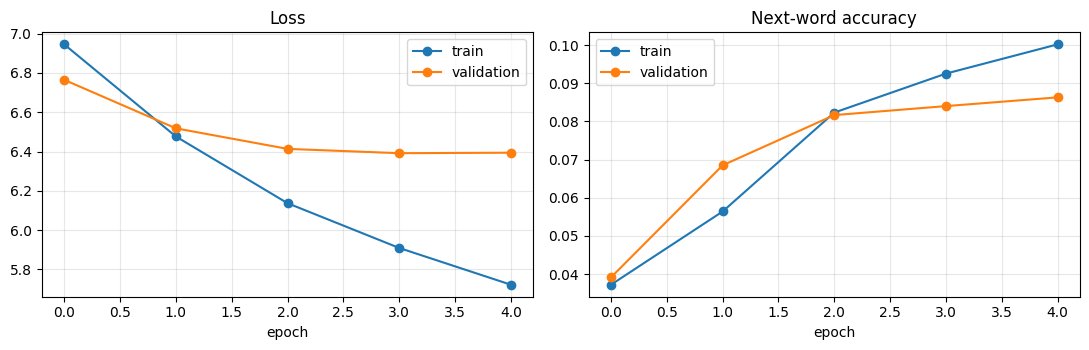

 epoch     loss  val_loss      acc  val_acc     gap
---------------------------------------------------
     1   6.9456    6.7651   0.0372   0.0391 -0.0019
     2   6.4768    6.5183   0.0564   0.0685 -0.0121
     3   6.1372    6.4137   0.0823   0.0816  0.0007
     4   5.9094    6.3917   0.0925   0.0840  0.0085
     5   5.7223    6.3941   0.1002   0.0863  0.0139

Random guessing over 12,848 words = 0.00008 accuracy; this model reaches 0.0863 (1109x better than chance).


In [7]:
import matplotlib.pyplot as plt

h = history.history

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(h["loss"], marker="o", label="train")
axes[0].plot(h["val_loss"], marker="o", label="validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch")
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(h["accuracy"], marker="o", label="train")
axes[1].plot(h["val_accuracy"], marker="o", label="validation")
axes[1].set_title("Next-word accuracy"); axes[1].set_xlabel("epoch")
axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

# The gap between the two accuracy lines IS the overfitting: the model keeps
# getting better on text it has seen while validation lags behind.
print(f"{'epoch':>6}{'loss':>9}{'val_loss':>10}{'acc':>9}{'val_acc':>9}{'gap':>8}")
print("-" * 51)
for i in range(len(h["loss"])):
    gap = h["accuracy"][i] - h["val_accuracy"][i]
    print(f"{i+1:>6}{h['loss'][i]:>9.4f}{h['val_loss'][i]:>10.4f}"
          f"{h['accuracy'][i]:>9.4f}{h['val_accuracy'][i]:>9.4f}{gap:>8.4f}")

baseline = 1 / total_words
print()
print(f"Random guessing over {total_words:,} words = {baseline:.5f} accuracy;"
      f" this model reaches {max(h['val_accuracy']):.4f}"
      f" ({max(h['val_accuracy']) / baseline:.0f}x better than chance).")

## 6. Test-set evaluation

`val_accuracy` is not a clean measure of quality here: `EarlyStopping` and
`ModelCheckpoint` both *choose* the model using validation loss, so the
validation set has influenced which weights were kept. The test set below had
no part in training or model selection, so it is the number to trust.

**How to read it:**

| Pattern | Meaning |
|---|---|
| test ≈ validation | the model generalises consistently — trained properly |
| test ≪ validation | the validation split was unrepresentative or over-selected |
| train ≫ test | overfitting — memorising training text |

In [8]:
# Evaluate on a training slice too, so all three numbers are measured the same
# way. The per-epoch training accuracy Keras prints is a running average taken
# *during* the epoch, so it is not directly comparable.
train_loss, train_acc = model.evaluate(X_train[-n_test:], y_train[-n_test:], verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

val_loss = min(h["val_loss"])
val_acc = h["val_accuracy"][int(np.argmin(h["val_loss"]))]

print(f"{'split':<14}{'loss':>10}{'accuracy':>11}")
print("-" * 35)
print(f"{'train':<14}{train_loss:>10.4f}{train_acc:>11.4f}")
print(f"{'validation':<14}{val_loss:>10.4f}{val_acc:>11.4f}")
print(f"{'TEST':<14}{test_loss:>10.4f}{test_acc:>11.4f}")

print()
print(f"train - test accuracy gap : {train_acc - test_acc:+.4f}")
print(f"test vs random guessing   : {test_acc / (1 / total_words):.0f}x better")
print(f"test perplexity           : {np.exp(test_loss):,.0f} "
      f"(out of {total_words:,} possible words)")

if abs(test_acc - val_acc) < 0.02:
    print()
    print("Test tracks validation -> the model generalises consistently.")
else:
    print()
    print("Test and validation disagree -> treat the validation number with caution.")

split               loss   accuracy
-----------------------------------
train             6.3464     0.0835
validation        6.3917     0.0840
TEST              6.6809     0.0774

train - test accuracy gap : +0.0061
test vs random guessing   : 995x better
test perplexity           : 797 (out of 12,848 possible words)

Test tracks validation -> the model generalises consistently.


## 6. Generate text

Same loop as the reference: tokenise the seed, pad it, predict, append the new
word, repeat.

**One difference:** the predicted word is *sampled* from the distribution
rather than taken with `np.argmax`. `argmax` is deterministic, so once the
model revisits a state it has already seen it repeats the same phrase forever —
the classic `"and the king and the king and the king"` loop. `temperature`
controls the randomness: low is safe and repetitive, high is varied and
sloppier. 0.7–1.0 works well here.

In [9]:
def generate_story(seed_text, next_words=50, temperature=0.8):
    '''Continue seed_text for next_words words, one prediction at a time.'''
    result = seed_text.lower().split()

    for _ in range(next_words):
        token_list = [word2idx[w] for w in result if w in word2idx]
        token_list = pad_sequences([token_list], maxlen=max_length - 1,
                                   padding="pre")

        probs = model.predict(token_list, verbose=0)[0].astype("float64")

        # temperature sampling instead of argmax
        probs = np.log(np.maximum(probs, 1e-10)) / temperature
        probs = np.exp(probs - probs.max())
        probs = probs / probs.sum()
        predicted_index = int(np.random.choice(len(probs), p=probs))

        result.append(idx2word.get(predicted_index, ""))

    return " ".join(w for w in result if w)


print(generate_story("in the hustle and bustle of", next_words=40))

in the hustle and bustle of my voices straight never can be a time of the alive whole sovereign duke councilhouse citizen enemies night i give ocean citizen feesimple gest highness simois compass of the chances name for a whole words skitless flecked bruised rails jointstools


## 7. Sample outputs

Several seeds, each at two temperatures.

In [10]:
SEEDS = [
    "first citizen we are",
    "my lord the king",
    "to be or not to be",
    "what news from verona",
]

for seed in SEEDS:
    print("=" * 70)
    print(f"SEED: {seed}")
    print("=" * 70)
    for temp in [0.6, 1.0]:
        print(f"\n--- temperature {temp} ---")
        print(generate_story(seed, next_words=40, temperature=temp))
    print()

SEED: first citizen we are

--- temperature 0.6 ---
first citizen we are a king and what i know not not not done you that we will not the crown and a king i fear you have all the house of a world that i am not the point of a king charity

--- temperature 1.0 ---
first citizen we are to rise for antigonus himself hark time says with me armd tears the molehill that life not king any but all that here is touchd but in the father and he but which then not tis the duke to my

SEED: my lord the king

--- temperature 0.6 ---
my lord the king that we have almost behold me to they am my life be a king you have not that i will the king is done at a little king and i will be a king you have not the king the

--- temperature 1.0 ---
my lord the king in reek of off and they had cunning and omnipotent she and move i please i not king you bear it as you warrant it o thou hast no eyes and two too o i have seen we watch thou

SEED: to be or not to be

--- temperature 0.6 ---
to be or not to be my cheek

## 8. Dataset and notes

**Dataset — Tiny Shakespeare** (public domain), downloaded automatically in §1:

```
https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
```

Also on Project Gutenberg: <https://www.gutenberg.org/ebooks/100>. Any `.txt`
file works — only `DATA_URL` changes, since the vocabulary is built from the
text itself.

### Notes on what to expect

- **Every generated token is a real word.** That's the advantage of a
  word-level model over a character-level one — it cannot invent spellings.
- **It repeats more than a character model does.** With ~200,000 words and a
  ~12,000-word vocabulary, the average word is seen about 16 times, which is
  not much to learn from. Common words dominate the predictions.
- **Rare words are effectively unlearnable** — a word appearing once or twice
  never gets enough gradient signal.
- **The seed must use known words.** Anything outside the vocabulary is
  silently dropped, so an out-of-vocabulary seed gives the model less context
  than you typed.

### If you want better output

1. **More text.** The binding constraint is data, not architecture — the full
   Gutenberg Shakespeare is ~5× this corpus.
2. **Trim the vocabulary.** Replace words appearing once or twice with an
   `<unk>` token; it shrinks the softmax and concentrates learning on words
   with enough examples.
3. **Go character-level.** With this much text a character model generally
   produces more coherent passages, at the cost of occasionally inventing a
   word.